In [50]:
# DAVID SANTIAGO PAEZ
# 28/04/2026

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
from sklearn.datasets import fetch_california_housing  #Se importa el dataset

data = fetch_california_housing()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['PRICE'] = data.target

print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  PRICE  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [4]:
df.sample(5)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
19854,1.9342,32.0,4.899573,0.995726,1538.0,3.286325,36.39,-119.31,0.686
3046,2.4044,34.0,5.478632,1.079772,1101.0,3.136752,35.50,-119.28,0.658
11258,2.8042,26.0,4.017982,1.079920,2457.0,2.454545,33.81,-117.97,2.063
1629,8.7589,32.0,6.895349,0.934109,721.0,2.794574,37.89,-122.16,4.345
7955,1.9903,18.0,4.258845,1.232775,1804.0,3.359404,33.88,-118.16,1.703


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
PRICE,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000


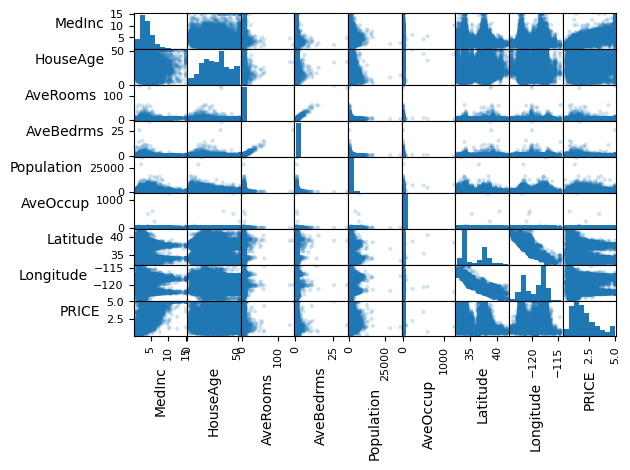

In [7]:
axes = pd.plotting.scatter_matrix(df, alpha=0.2)

for ax in axes.flatten():
    ax.xaxis.label.set_rotation(90) #gira el texto del eje X
    ax.yaxis.label.set_rotation(0)  #deja el eje Y horizontal
    ax.yaxis.label.set_ha('right')  #alinea el texto a la derecha

plt.tight_layout() #organiza automáticamente los espacios, evita que se sobrepongan
plt.gcf().subplots_adjust(wspace=0, hspace=0) # elimina espacios entre gráficos, wspace → espacio horizontal, hspace → espacio vertical
plt.show()

In [8]:
df = df.drop(['AveBedrms','Population','AveOccup','Longitude'], axis=1)

In [9]:
df.head(5)

,MedInc,HouseAge,AveRooms,Latitude,PRICE
0,8.3252,41.0,6.984127,37.88,4.526
1,8.3014,21.0,6.238137,37.86,3.585
2,7.2574,52.0,8.288136,37.85,3.521
3,5.6431,52.0,5.817352,37.85,3.413
4,3.8462,52.0,6.281853,37.85,3.422


In [10]:
X = df[['MedInc', 'AveRooms', 'HouseAge', 'Latitude']].to_numpy()
y = df[['PRICE']].to_numpy()

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [14]:
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)

Coeficientes: [[ 0.83266855 -0.05402046  0.21332739 -0.09673758]]
Intercepto: [2.06870373]


In [15]:


y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 0.599391354862759
MSE: 0.6495475488975627
RMSE: 0.8059451277212133
R2: 0.5043169272470043


In [ ]:
# -----------------------------------
# REGRESION POLINOMIAL GRADO 2
# -----------------------------------

In [1]:
from sklearn.preprocessing import PolynomialFeatures


In [27]:
poly_2 = PolynomialFeatures(degree=2)  #creamos variables polinomiales de grado 2
X_poly_2 = poly.fit_transform(X_scaled)

In [28]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_poly_2, y, test_size=0.2, random_state=42) # volvemos a Train/Test pero ahora con x_poly

In [30]:
model_2 = LinearRegression() #Entrenamos el modelo
model_2.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred2 = model_2.predict(X_test)

print("R2", r2_score(y_test, y_pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))


R2 0.5188088206555673
RMSE 0.7940763449840774
MAE 0.583226336527561
MSE 0.6305572416632715


In [23]:
# -----------------------------------
# REGRESION POLINOMIAL GRADO 3
# -----------------------------------

In [33]:
poly_3 = PolynomialFeatures(degree=3)
X_poly_3 = poly_3.fit_transform(X_scaled)

In [42]:
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_poly_3, y, test_size=0.2, random_state=42) # volvemos a Train/Test pero ahora con x_poly3

In [43]:
model_3 = LinearRegression() #Entrenamos el modelo
model_3.fit(X_train_3, y_train_3)

LinearRegression()

In [44]:
y_pred_3 = model_3.predict(X_test_3)

print("R2", r2_score(y_test_3, y_pred_3))
print("RMSE", np.sqrt(mean_squared_error(y_test_3, y_pred_3)))

R2 0.5139495966010545
RMSE 0.7980756934599558


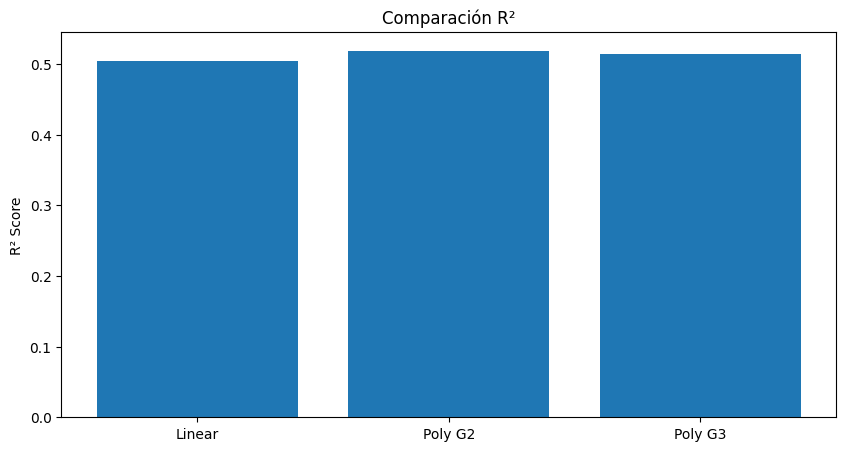

In [45]:
modelos = ['Linear', 'Poly G2', 'Poly G3']
r2_scores = [0.5043, 0.5188, 0.5139]
rmse_scores = [0.8059, 0.7940, 0.7980]

plt.figure(figsize=(10,5))
plt.bar(modelos, r2_scores)
plt.title("Comparación R²")
plt.ylabel("R² Score")
plt.show()

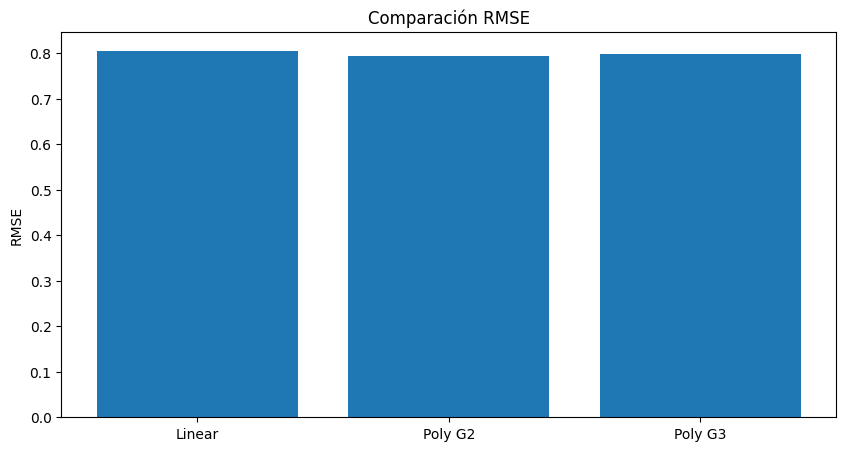

In [46]:
plt.figure(figsize=(10,5))
plt.bar(modelos, rmse_scores)
plt.title("Comparación RMSE")
plt.ylabel("RMSE")
plt.show()

In [47]:
results = pd.DataFrame({
    'Modelo': ['Linear Regression', 'Polynomial G2', 'Polynomial G3'],
    'R2': [0.5043, 0.5188, 0.5139],
    'RMSE': [0.8059, 0.7940, 0.7980]
})

results

,Modelo,R2,RMSE
0,Linear Regression,0.5043,0.8059
1,Polynomial G2,0.5188,0.7940
2,Polynomial G3,0.5139,0.7980
